# Gradientes del barrido VQE
Esta visualización usa los historiales de norma del gradiente guardados durante los 30 VQE. No vuelve a ejecutar ningún circuito.

In [1]:
from pathlib import Path
import json
import sys
import matplotlib.pyplot as plt
import numpy as np
NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / 'results').exists():
    NOTEBOOK_DIR = Path('Tensor Networks/ising con campo transverso').resolve()
RESULTS_DIR = NOTEBOOK_DIR / 'results'
VQE_PATH = RESULTS_DIR / 'all_vqe_results_adam500_later150_lbfgs80.json'
if not VQE_PATH.exists():
    VQE_PATH = RESULTS_DIR / 'all_vqe_results.json'
rows = json.loads(VQE_PATH.read_text(encoding='utf-8'))
fields = np.asarray(sorted({row['transverse_field_h'] for row in rows}), dtype=float)
assert len(rows) == 30
print(f'{len(rows)} historiales cargados; {len(fields)} campos y 3 semillas por campo.')

30 historiales cargados; 10 campos y 3 semillas por campo.


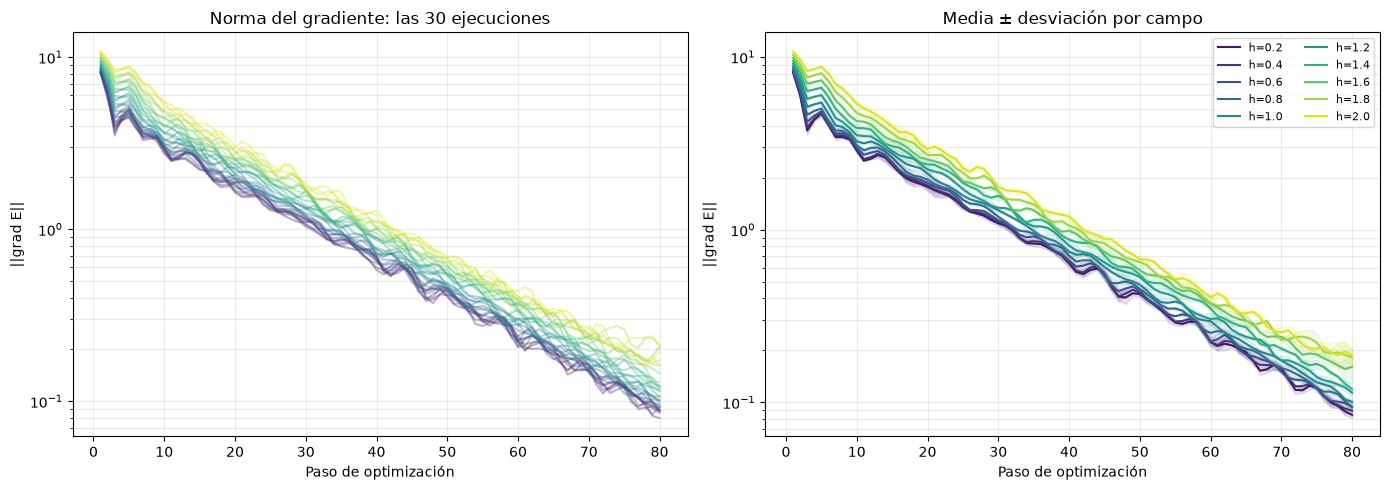

In [2]:
colors = plt.cm.viridis(np.linspace(0.05, 0.95, len(fields)))
color_by_field = {float(field): colors[index] for index, field in enumerate(fields)}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for row in rows:
    history = np.asarray(row['gradient_norm_history'], dtype=float)
    steps = np.arange(1, len(history) + 1)
    axes[0].semilogy(steps, history, color=color_by_field[float(row['transverse_field_h'])], alpha=0.35)
for field, color in color_by_field.items():
    histories = np.asarray([row['gradient_norm_history'] for row in rows if row['transverse_field_h'] == field])
    mean = histories.mean(axis=0)
    std = histories.std(axis=0)
    steps = np.arange(1, len(mean) + 1)
    axes[1].semilogy(steps, mean, color=color, label=f'h={field:.1f}')
    axes[1].fill_between(steps, np.maximum(mean - std, 1e-12), mean + std, color=color, alpha=0.12)
axes[0].set_title('Norma del gradiente: las 30 ejecuciones')
axes[0].set_xlabel('Paso de optimización')
axes[0].set_ylabel('||grad E||')
axes[1].set_title('Media ± desviación por campo')
axes[1].set_xlabel('Paso de optimización')
axes[1].set_ylabel('||grad E||')
axes[1].legend(ncol=2, fontsize=8)
for axis in axes:
    axis.grid(alpha=0.25, which='both')
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'vqe_gradient_norms.png', dpi=180)
plt.show()

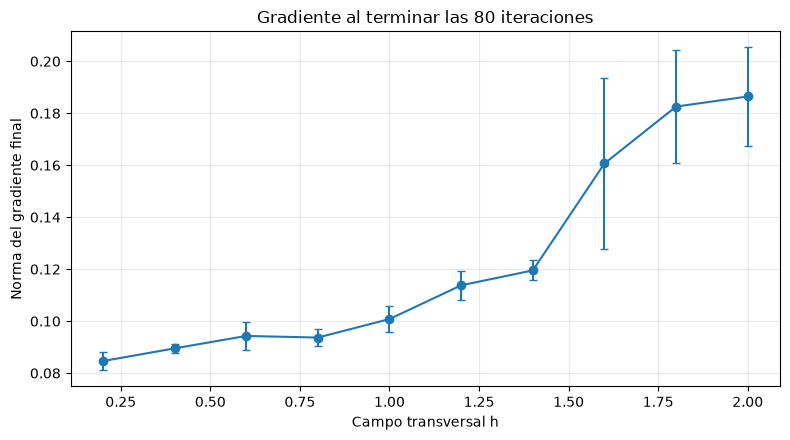

Gradiente final medio global: 1.225867e-01


In [3]:
fig, axis = plt.subplots(figsize=(8, 4.5))
final_means = []
final_stds = []
for field in fields:
    values = [row['gradient_norm_history'][-1] for row in rows if row['transverse_field_h'] == field]
    final_means.append(np.mean(values))
    final_stds.append(np.std(values))
axis.errorbar(fields, final_means, yerr=final_stds, fmt='o-', capsize=3)
axis.set_xlabel('Campo transversal h')
axis.set_ylabel('Norma del gradiente final')
axis.set_title('Gradiente al terminar las 80 iteraciones')
axis.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'vqe_final_gradient_by_field.png', dpi=180)
plt.show()
print(f'Gradiente final medio global: {np.mean(final_means):.6e}')